# Topological Data Analysis: The Mapper Algorithm

The Mapper algorithm is a technique used in topological data analysis to visualize high-dimensional datasets in lower-dimensional structures while preserving information about the connectivity between data points. It works by dividing the feature space using a cover and constructing a simplicial complex that represents the relationships between these regions through a clustering process applied to each subset. Mapper produces a simplified representation of the original dataset, facilitating pattern identification and improving the understanding of the underlying structure of the data.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.cluster import DBSCAN
import operator
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from IPython.display import display, HTML
from scipy.spatial import distance_matrix
from math import sqrt
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection

In [2]:
! pip install kmapper
import kmapper as km

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.7 MB/s eta 0:00:00


# Dataset

We will use the **Most Subscribed YouTube Channels** dataset by Sukhmandeep Singh Brar, which can be accessed on Kaggle through the following link. https://www.kaggle.com/datasets/sukhmandeepsinghbrar/most-subscribed-youtube-channel?resource=download.

This dataset contains the top 50 YouTube channels with the highest number of subscribers, represented by the following variables:

<table>
  <tr>
    <th>Variable</th>
    <th>Type</th>
    <th>Description</th>
    <th>Useful</th>
  </tr>
  <tr>
    <td>Name</td>
    <td>String</td>
    <td>YouTube channel's name</td>
    <th>No</th>
  </tr>
  <tr>
    <td>Brand channel</td>
    <td>String</td>
    <td>Yes/No if the channel is a brand one</td>
    <th>Yes</th>
  </tr>
  <tr>
    <td>Subscribers (millions)</td>
    <td>Float</td>
    <td>Number of channel's subscribers</td>
    <th>Yes</th>
  </tr>
  <tr>
    <td>Primary language</td>
    <td>String</td>
    <td>Channel's primary language</td>
    <th>Yes</th>
  </tr>
  <tr>
    <td>Category</td>
    <td>String</td>
    <td>Channel's content category</td>
    <th>Yes</th>
  </tr>
  <tr>
    <td>Country</td>
    <td>String</td>
    <td>Country of procedence of the owner</td>
    <th>Yes</th>
  </tr>
</table>

In [277]:
data = pd.read_csv('Most Subscribed YouTube Channels_exported.csv')
data.head()

,Name,Brand channel,Subscribers (millions),Primary language,Category,Country
0,T-Series,Yes,249.0,Hindi[7][8],Music,India
1,MrBeast,No,184.0,English,Entertainment,United States
2,Cocomelon,Yes,165.0,English,Education,United States
3,Sony Entertainment Television India,Yes,162.0,Hindi[9],Entertainment,India
4,Kids Diana Show,Yes,113.0,English[10][11][12],Entertainment,Ukraine- United States


# Data Cleaning

We modified the **Category** column to avoid duplication of the same language appearing with different numerical labels.

In [6]:
data["Primary language"] = data["Primary language"].apply(lambda x: x.split("[")[0])

# Exploratory Data Analysis and Variable Selection

For simplicity, we will assume that the **Name** variable only serves to identify each observation and does not characterize it, in order to avoid working with language models. However, the remaining variables will be considered relevant for characterizing the data.

Next, we visualize the distribution of the values of the remaining five variables (from now on referred to simply as *the variables*).

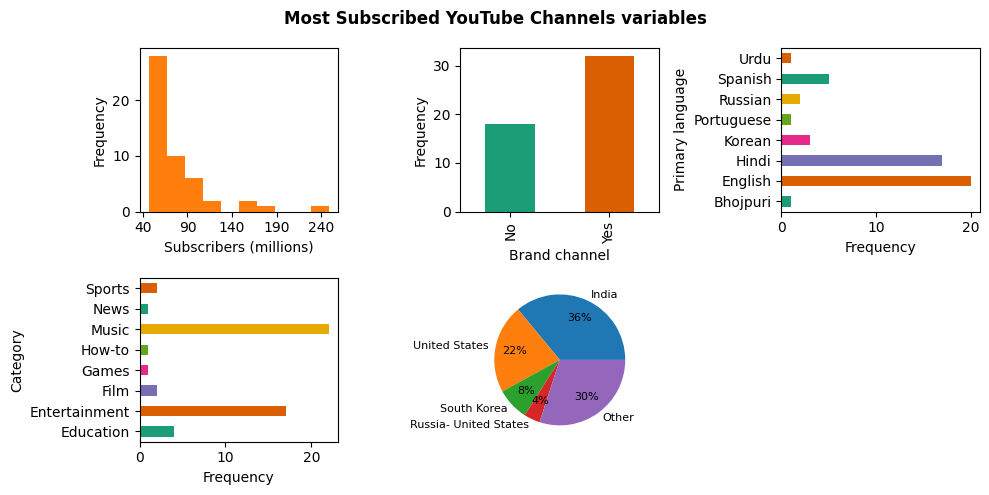

In [7]:
fig,ax = plt.subplots(2,3,figsize=(10,5))
data["Subscribers (millions)"].plot(kind="hist",ax=ax[0,0],density=False, grid=False, xlabel="Subscribers (millions)",
                                    ylabel="Frequency", xticks=range(40,270,50), color="tab:orange")
data.groupby('Brand channel').size().plot(kind='bar', color=sns.palettes.mpl_palette('Dark2'),ax=ax[0,1], ylabel="Frequency")
data.groupby('Primary language').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'),ax=ax[0,2], xlabel="Frequency")
data.groupby('Category').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'),ax=ax[1,0], xlabel="Frequency")
ax[1,2].remove()
countries = data.groupby('Country').size().sort_values(ascending=False)
remaining = countries[4:].sum()
countries = countries[:4]
countries.loc["Other"] = remaining
countries.plot.pie(ax=ax[1,1],autopct='%1.0f%%',fontsize=8,pctdistance=0.7)
fig.suptitle("Most Subscribed YouTube Channels variables",weight="bold")
plt.tight_layout()
plt.show()

# Variable Encoding

We define the notation $\mathcal{D}_V=\{v_i\}_{i=1}^N$ to represent the original dataset, where the tuple $v_i=(v_i^1,\dots,v_i^5)$ contains the values of the variables for the $i$-th observation.

Since most of the variables are categorical, we will transform the continuous variable ( v^1 ) into a categorical one in order to simplify the analysis and compute distances using the Hamming metric.

To do this, we will classify each value of the **Subscribers (millions)** variable as belonging to one of the following intervals, defined by the 0.6 and 0.9 quantiles of that variable.


<table>
  <tr>
    <th>Category</th>
    <th>Interval</th>
  </tr>
  <tr>
    <td>1</td>
    <td>[0-quantile, 0.6-quantile)</td>
  </tr>
  <tr>
    <td>2</td>
    <td>[0.6-quantile, 0.9-quantile)</td>
  </tr>
    <tr>
    <td>3</td>
    <td>[0.9-quantile, 1-quantile]</td>
  </tr>
</table>

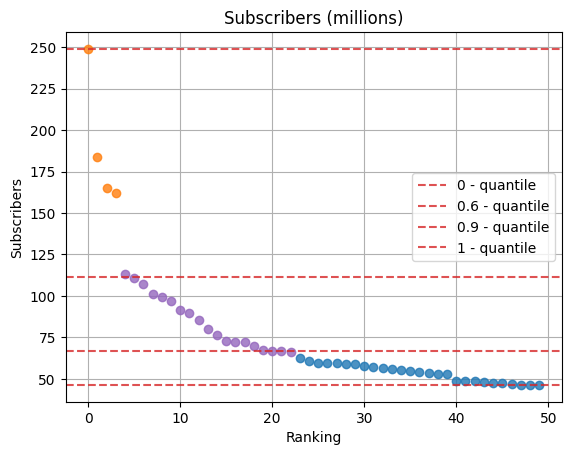

In [278]:
fig,ax = plt.subplots()
data["Subscribers (millions)"].iloc[:4].plot(linestyle="None",marker="o",ax=ax,color="tab:orange",label="",alpha=0.8)
data["Subscribers (millions)"].iloc[4:23].plot(linestyle="None",marker="o",ax=ax,color="tab:purple",label="",alpha=0.8)
data["Subscribers (millions)"].iloc[23:].plot(linestyle="None",marker="o",ax=ax,color="tab:blue",label="",alpha=0.8)
ax.set_title("Subscribers (millions)")
ax.set_xlabel("Ranking")
ax.set_ylabel("Subscribers")
for q,value in zip([0,0.6,0.9,1],np.quantile(data["Subscribers (millions)"],[0,0.6,0.9,1])):
    ax.axhline(value,linestyle="--",color="tab:red",label=f"{q} - quantile",alpha=0.8)
ax.legend()
ax.grid()
plt.show()

In [9]:
encoder = dict()
decoder = dict()
quant = np.quantile(data["Subscribers (millions)"],[0,0.6,0.9])

for col in ["Brand channel","Primary language","Category","Country"]:
  encoder.update({col:dict([(x,i) for i,x in enumerate(np.unique(data[col]))])})
  decoder.update({col:dict(map(lambda x: (x[1],x[0]), encoder[col].items()))})

Now, to ensure that two values $a$ and $b$ of this variable that are “far apart” remain “far apart” under the Hamming metric, we encode each category value as an ordered triplet as follows:

| Category | Encoding |
| -------- | -------- |
| 1        | (0,0,1)  |
| 2        | (0,1,1)  |
| 3        | (1,1,1)  |

Thus, the distance between categories $k$ and $k+1$ is 1, while the distance between 1 and 3 is 2. We denote this transformation by the function
$\epsilon_1:\mathbb{R} \to \mathbb{Z}^3$.

For the remaining categorical variables, if $\tau^j_1, \dots, \tau^j_{n_j}$ are the possible values of the categorical variable $v^j$, we apply the encoding
$\tau^j_k \mapsto k$
(under some indexing of $\tau^j_k$) to represent each category value numerically. We denote this transformation by the function
$\epsilon_j:\{\tau_k^j\}_{k=1}^{n_j}→\mathbb{Z}$.

In this way, we define the overall data encoding function
$\epsilon: V \to \mathbb{Z}^7$
through its component functions as
$\epsilon(v) = (\epsilon_1(v), \dots, \epsilon_5(v))$. Thus, the new variable $x$ is defined by

$$v_i \mapsto \epsilon(v_i) = x_i$$

for every $v_i \in \mathcal{D}_V$.


In [10]:
X = np.hstack((pd.get_dummies(data["Subscribers (millions)"].apply(lambda x: quant[x >= quant][-1]))[quant[::-1]].to_numpy().astype(int) @ np.array([[1,1,1],[0,1,1],[0,0,1]]),
               *tuple(data[col].apply(lambda x: encoder[col][x]).to_numpy().reshape(-1,1) for col in ["Brand channel","Primary language","Category","Country"])))

In this waw, we build the data matrix
$$X=\begin{pmatrix}x_1^1 & \cdots & x_1^7\\\vdots & \ddots & \vdots\\ x_{50}^1 & \cdots & x_{50}^7\end{pmatrix}\in\mathbb{Z}^{50\times 7}$$

For example, some of its elements can be visualized as follows

In [281]:
X[(np.random.sample(5)*50).astype(int)]

array([[ 0,  0,  1,  0,  1,  5, 17],
       [ 0,  0,  1,  0,  1,  5, 17],
       [ 0,  1,  1,  0,  1,  1, 14],
       [ 1,  1,  1,  1,  2,  1,  7],
       [ 0,  0,  1,  1,  0,  5,  7]])

# Distance Matrix

As mentioned above, we will analyze the data using the Hamming distance:

$$d_H(x,y) = \#\{x_i \neq y_i\}_{i=1}^n$$

Using this metric, we construct the distance matrix

$$D=\begin{pmatrix}d_H(x_1,x_1) & \cdots & d_H(x_1,x_{50})\\\vdots & \ddots & \vdots\\ d_H(x_{50},x_1) & \cdots & d_H(x_{50},x_{50})\end{pmatrix}\in\mathbb{R}^{50\times 50}$$

To simplify the generation of subsequent visualizations, we scale the distances by a factor of $1/7$, where 7 is the maximum possible Hamming distance between a pair of data points. In this way, $D_{ij} \in [0,1]$ for all $ i,j \leq 50 $.


In [285]:
D = np.zeros((X.shape[0],X.shape[0]))
for i in range(X.shape[0]):
  for j in range(X.shape[0]):
    D[i,j] = np.sum(X[i] != X[j]) / 7

Now, lets visualize the distance matrix and the empirical distribution function of its values.

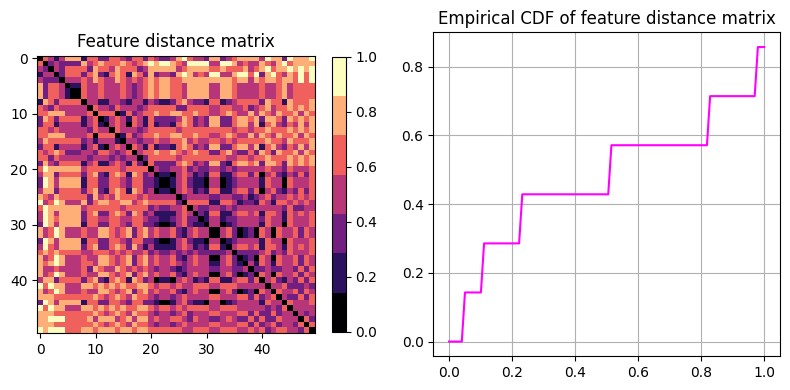

In [15]:
fig,ax = plt.subplots(1,2,figsize=(8,4))
cmap = plt.get_cmap("magma",np.unique(D).size)
ax[0].imshow(D,cmap="magma")
plt.colorbar(ScalarMappable(cmap=cmap),ax=ax[0],shrink=0.85)
ax[0].set_title("Feature distance matrix")
ax[1].plot(np.linspace(0,1,100),np.quantile(D.reshape(-1),np.linspace(0,1,100)),color="magenta")
ax[1].set_title(r"Empirical CDF of feature distance matrix")
ax[1].grid()
plt.tight_layout()
plt.show()

# Filter Function

In this section, lets test several filter functions to project the data.

In [211]:
def plot_lens(lens,colormap="gnuplot",mapped_text=True,original_text=True):
  fig,ax = plt.subplots(figsize=(16,4))
  cmap = plt.get_cmap(colormap,lens.size)
  ax.scatter(np.linspace(0,1,lens.size),0.8*np.ones(lens.size),marker="o",alpha=0.8,c=np.arange(lens.size),cmap=colormap)
  ax.scatter(lens[:,0],0.2*np.ones(lens.size),marker="o",alpha=0.8,c=np.arange(lens.size),cmap=colormap)
  x = np.linspace(0,1,lens.size)
  for i in range(lens.size):
    ax.plot([lens[i,0],x[i]],[0.2,0.8],color=cmap(x[i]),alpha=0.4)
  if mapped_text:
    for t in np.unique(lens):
      idx = np.where(np.abs(lens-t)<0.0001)[0]
      ax.text(t-0.005,0.1-0.037*idx.size,"".join([str(i)+"\n" for i in idx]),fontsize=8,rotation=0,color=cmap(x[idx[0]]))
  if original_text:
    for i in range(x.size):
      ax.text(x[i]-0.005,0.85,str(i),fontsize=8,rotation=0,color=cmap(x[i]))
  ax.set_yticks([])
  ax.set_xticks(np.arange(0,1.1,0.1))
  ax.set_ylim(-0.1,1)
  return fig,ax

def min_max_scaling(X):
  return (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

## Data Depth

To quantify the centrality of a point $x\in X$ define the **data depth** as the filter

$$DD(x) = \frac{1}{N}\sum_{y\in X}d(x,y)$$

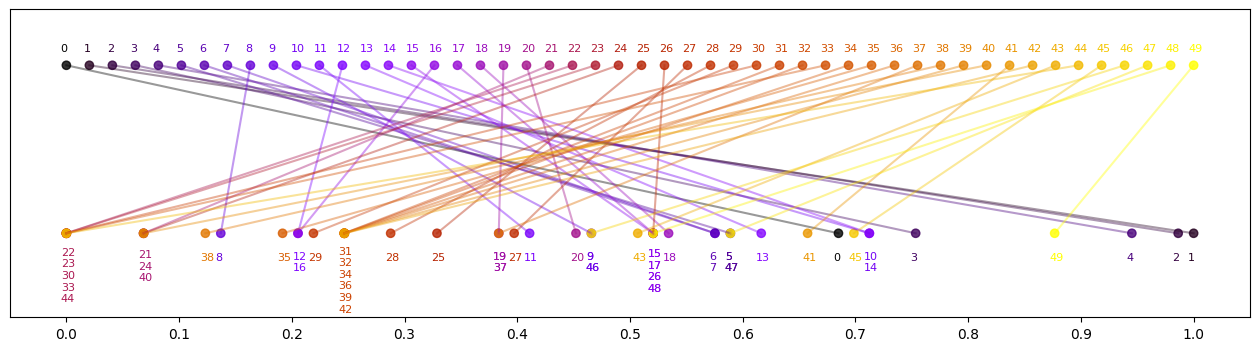

In [212]:
def data_depth_filter(D):
  L = D.mean(axis=1,keepdims=True)
  lens = min_max_scaling(L)
  return lens

plot_lens(data_depth_filter(D))
plt.show()

## Density

Let $k\in\mathbb{Z}_+$ and $x,x_k\in X$ such that $x_k$ is the $k$-th nearest neighbour of $x$. Define the **density** as the filter

$$\delta(x)=\frac{1}{d(x,x_k)}$$

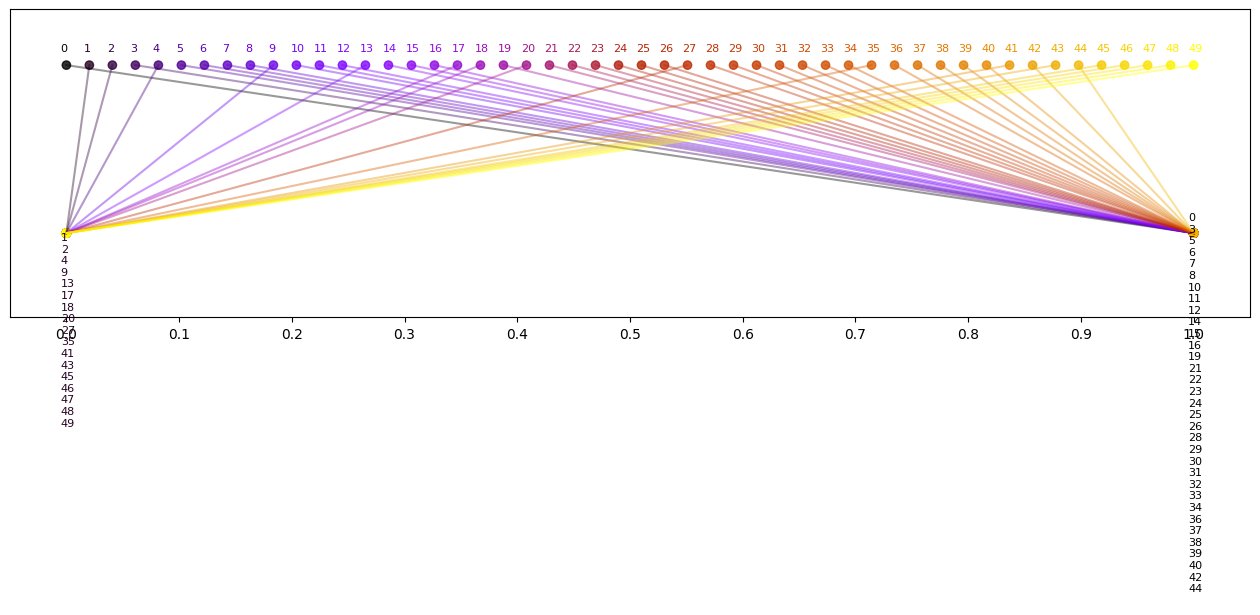

In [213]:
def density_filter(D):
  R = D.copy()
  R[R==0] = 1
  L = 1/R.min(axis=1,keepdims=True)
  lens = min_max_scaling(L)
  return lens

plot_lens(density_filter(D))
plt.show()

## Gaussian Kernel

Let $\alpha>0$ define the Gaussian Kernel as
$$K_\alpha(x) = C_\alpha\sum_{y\in X}\exp\left(-\frac{d(x,y)^2}{\alpha}\right)$$
such that $\int K_\alpha(x)dx = 1$ and we use it as a **density** filter.

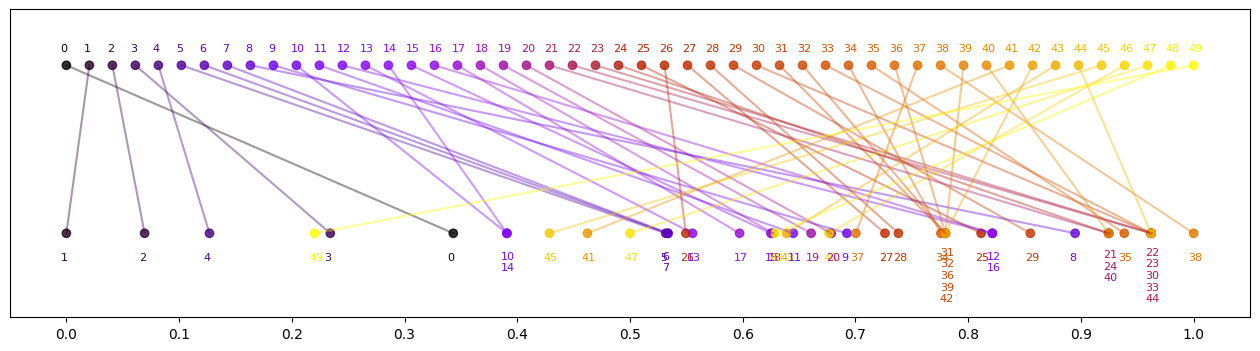

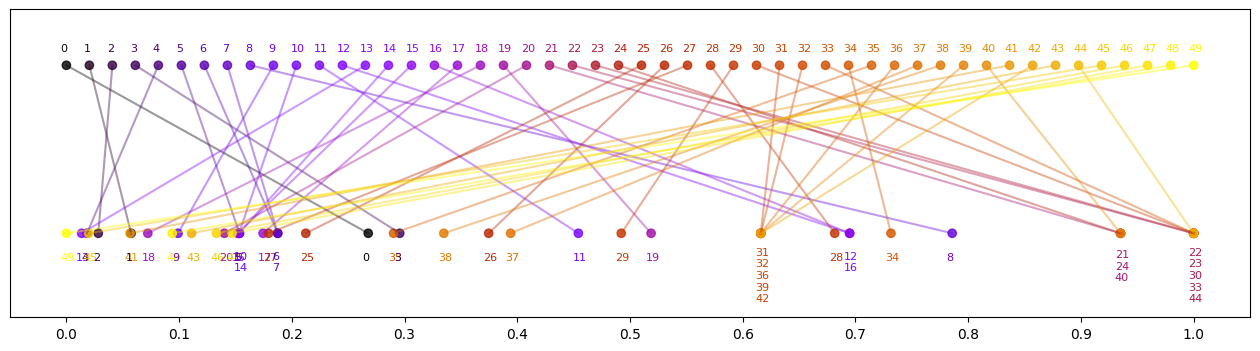

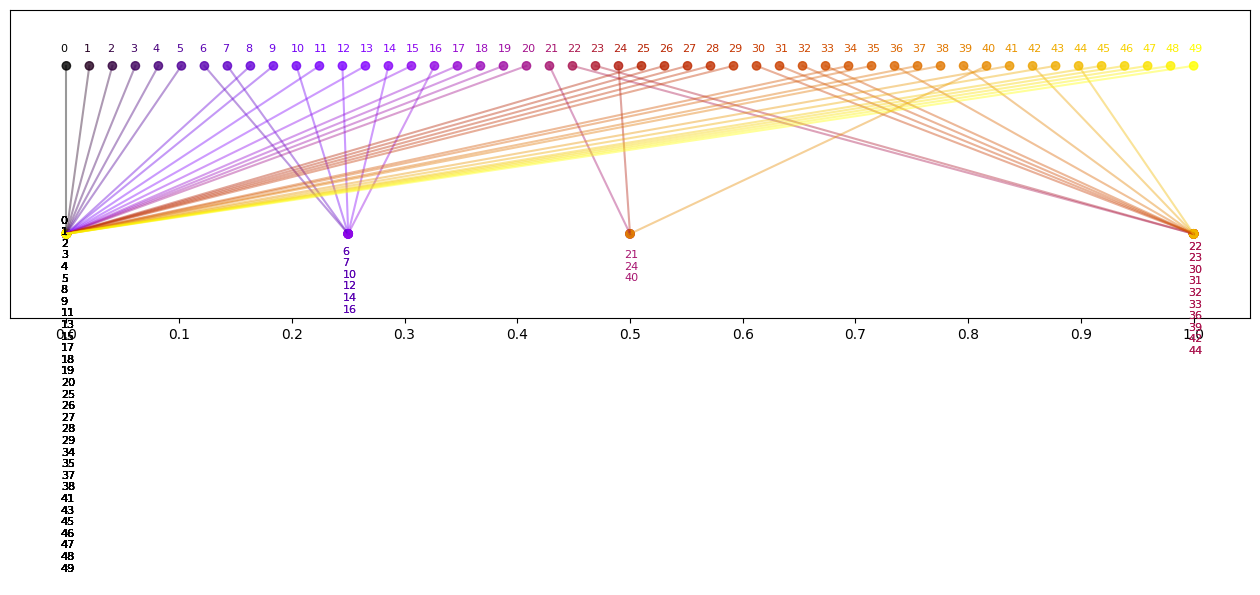

In [214]:
def gaussian_kernel_filter(D,alpha):
  L = (1/sqrt(2*3.1416*sqrt(alpha/2)))*np.exp(-D**2/alpha).sum(axis=1,keepdims=True)
  lens = min_max_scaling(L)
  return lens

plot_lens(gaussian_kernel_filter(D,1000))
plt.show()

plot_lens(gaussian_kernel_filter(D,0.05))
plt.show()

plot_lens(gaussian_kernel_filter(D,0.001))
plt.show()

## $L$-Centrality

To quantify the **centrality** of a point with respect to a point cloud, define the $L$-centrality filter as
$$LC(x) = \max_{y\in X} d(x,y)$$

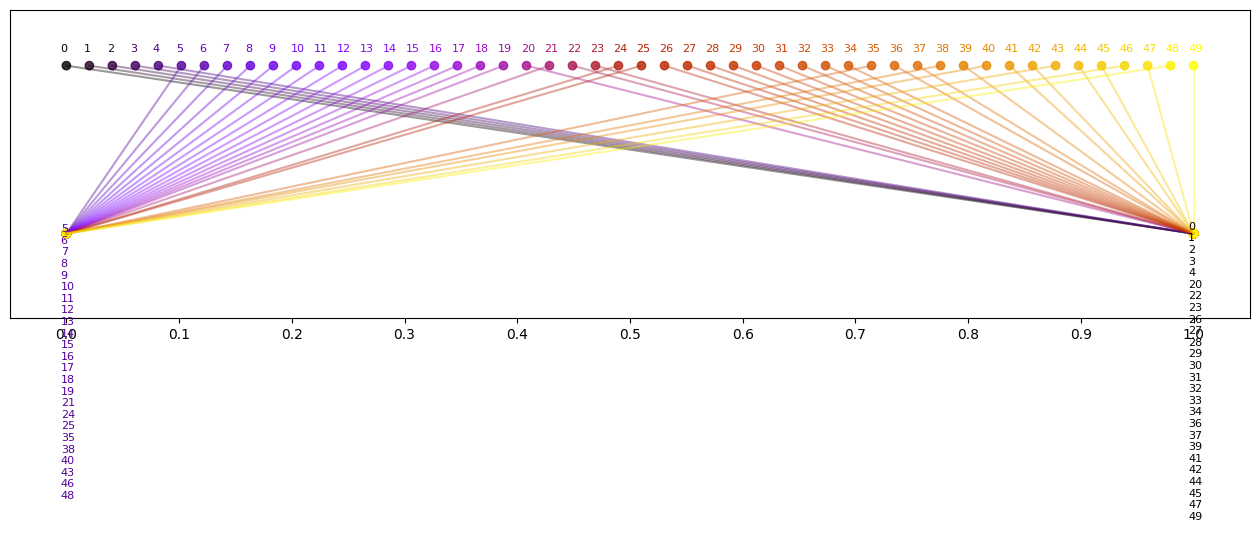

In [215]:
def l_centrality_filter(D):
  L = D.max(axis=1,keepdims=True)
  lens = min_max_scaling(L)
  return lens

plot_lens(l_centrality_filter(D))
plt.show()

## Excentricity

Let $1\leq p<\infty$ define the **excentricity** function
$$E_p(x) = \left(\frac{1}{N}\sum_{y\in X}d(x,y)^p\right)^{1/p}$$
as a filter that identifies points that are *"far from the center"*, without actually determining what does the *center* means.

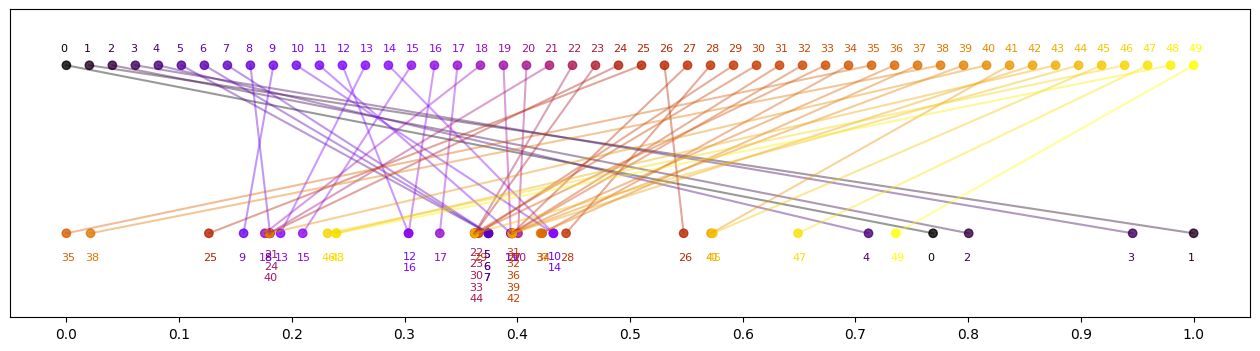

In [216]:
def excentricity_filter(D,p):
  L = ((D/D.shape[0]**(1/p))**p).sum(axis=1,keepdims=True)**(1/p)
  lens = min_max_scaling(L)
  return lens

plot_lens(excentricity_filter(D,10))
plt.show()

# The MAPPER algorithm

In this section, we apply the MAPPER algorithm to the dataset.

In [22]:
mapper = km.KeplerMapper(verbose=2)

KeplerMapper(verbose=2)


From the previous plots, we observe that several filters collapse the data image into a small number of points in $\mathbb{R}$, making the resulting clusterings trivial and rendering the execution of the algorithm unnecessary.

On the other hand, the Gaussian kernel with $\alpha = 1000$ and the eccentricity function were the filters that managed to generate noticeable density patterns in their images. Therefore, these were the ones studied throughout the development of this project.

However, the filter that produced the most interesting results was the one based on the eccentricity function, and it will be the one used for the subsequent analysis.


In [ ]:
lens = excentricity_filter(D,10)

For the MAPPER algorithm, we will use the [DBSCAN](https://en.wikipedia.org/wiki/DBSCAN) clustering method in order to avoid specifying in advance the number of clusters to be determined.

The image of the data under this filter (see the eccentricity plot) suggests using a cover with few intervals. Due to the high density in the central region, we adopt a small percentage of overlap. Similarly, considering the scale and density of the filter image, we use a value of ( \epsilon = 0.08 ) for the clustering step.

After several experiments, the following set of parameters was found to work adequately together to produce meaningful and interesting results.

In [286]:
graph = mapper.map(lens, clusterer=DBSCAN(eps=0.08, min_samples=2), cover=km.Cover(n_cubes=9, perc_overlap=0.2))

Mapping on data shaped (50, 1) using lens shaped (50, 1)

Minimal points in hypercube before clustering: 2
Creating 9 hypercubes.
   > Found 1 clusters in hypercube 0.
   > Found 1 clusters in hypercube 1.
   > Found 1 clusters in hypercube 2.
   > Found 1 clusters in hypercube 3.
   > Found 1 clusters in hypercube 4.
   > Found 1 clusters in hypercube 5.
   > Found 1 clusters in hypercube 6.
   > Found 1 clusters in hypercube 7.
   > Found 1 clusters in hypercube 8.

Created 4 edges and 9 nodes in 0:00:00.575630.


Lets export the results for an interactive visualization.

In [287]:
mapper.visualize(graph, path_html="output.html")

Wrote visualization to: output.html


'<!DOCTYPE html>\n<html>\n\n<head>\n  <meta charset="utf-8">\n  <meta name="generator" content="KeplerMapper">\n  <title>Kepler Mapper | KeplerMapper</title>\n\n  <link rel="icon" type="image/png" href="http://i.imgur.com/axOG6GJ.jpg" />\n\n  <link href=\'https://fonts.googleapis.com/css?family=Roboto+Mono:700,300\' rel=\'stylesheet\' type=\'text/css\'>\n  <style>* {\n  margin: 0;\n  padding: 0;\n}\n\nhtml, body {\n  height: 100%;\n}\n\nbody {\n  font-family: "Roboto Mono", "Helvetica", sans-serif;\n  font-size: 14px;\n}\n\n#logo {\n  width:  85px;\n  height: 85px;\n}\n\n#display {\n  color: #95A5A6;\n  background: #212121;\n}\n\n#header {\n  background: #111111;\n}\n\n#print {\n  color: #000;\n  background: #FFF;\n}\n\nh1 {\n  font-size: 21px;\n  font-weight: 300;\n  font-weight: 300;\n}\n\nh2 {\n  font-size: 18px;\n  padding-bottom: 20px;\n  font-weight: 300;\n}\n\nh3 {\n  font-size: 14px;\n  font-weight: 700;\n  text-transform: uppercase;\n}\n\nh4 {\n  font-size: 13px;\n  font-weigh

# Visualization of the MAPPER Algorithm

In this section, we extend the visualization of the filter image to display the generated cover, the clusters found, and the final simplicial complex in a way that makes it possible to understand how the original data relate to each stage of the MAPPER algorithm.

First, we obtain the simplices generated by `mapper.map()`, as well as the centers of each interval. Using these, we determine the value of ( l ), the length of the intervals.

In [271]:
nodes = dict(graph.get('nodes'))
links = dict(graph.get('links'))
vertices = np.array(list(map(lambda x: [x.split("_")[0].split("cube")[1],x.split("cluster")[1],np.array(nodes.get(x)).mean(),len(nodes.get(x))], nodes.keys()))).astype(float)
edges = np.array(list(map(lambda x: [x.split("_")[0].split("cube")[1],x.split("cluster")[1],
                            links.get(x)[0].split("_")[0].split("cube")[1],links.get(x)[0].split("cluster")[1]], links.keys()))).astype(int)

Let $c_1, \dots, c_n$ be the centers of a cover consisting of $n$ intervals, and let ( p ) denote the percentage of overlap. Then,

$$p = \frac{(c_{i}+l/2)-(c_{i+1}-l/2)}{l} $$

Therefore,

$$l = \frac{c_{i}-c_{i+1}}{p-1}$$

In this way, we can reconstruct the cover generated by `mapper.map()`.


In [272]:
_ = np.unique(lens).reshape(-1,1)
_ = np.hstack((_,_))
cov = km.Cover(n_cubes=9, perc_overlap=0.2)
cube_centers = cov.fit(_)
n = graph.get("meta_data").get("n_cubes")
p = graph.get("meta_data").get("perc_overlap")
l = ((cube_centers[0] - cube_centers[1])/ (p - 1))[0]
cover_left = np.arange(n)*l*(1-p)+cube_centers[0]-l/2
cover_right = np.arange(1,n+1)*l*(1+p)+cube_centers[0]-l/2
cover = np.hstack((cover_left.reshape(-1,1),cover_right.reshape(-1,1)))

Finaly, lets visualize the complete process that the MAPPER algorithm actually did to the data.

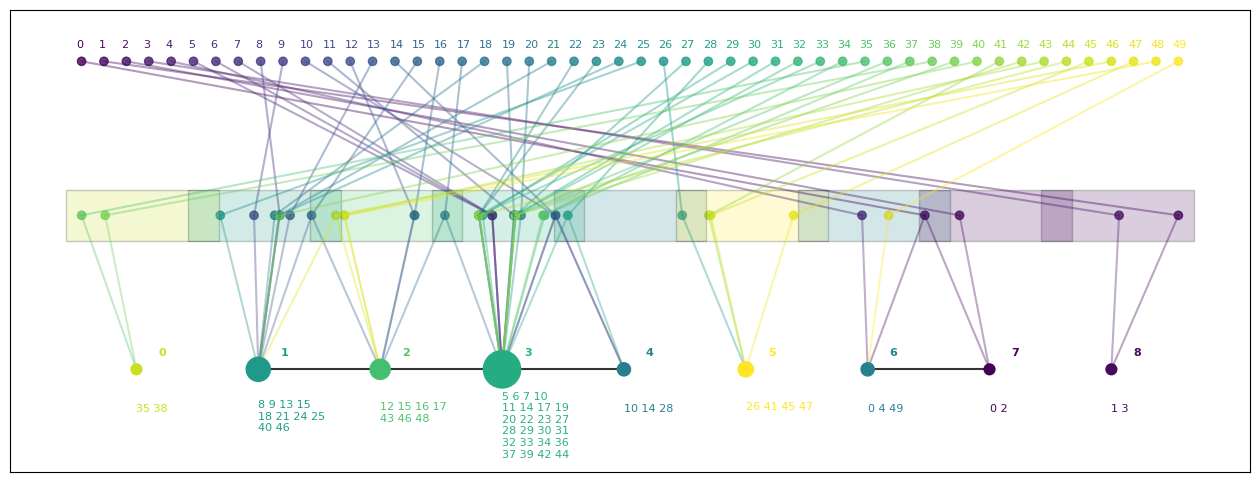

In [273]:
fig,ax = plot_lens(lens,"viridis",False)
cmap = plt.get_cmap("viridis",np.unique(lens).size)
covers = [Rectangle((cover[i,0], 0.1), l, 0.2) for i in range(cover.shape[0])]
pc = PatchCollection(covers, facecolor=cmap(vertices[:,2]/vertices[:,2].max()),cmap="viridis", alpha=0.2, edgecolor="black")
ax.add_collection(pc)
ax.set_yticks([])
ax.set_ylim(-0.8,1)
vert = vertices[:,0]/vertices.shape[0]+np.apply_along_axis(lambda x: x[0]/np.sum(vertices[:,0]==x[0])+0.05,arr=vertices[:,1].reshape(-1,1),axis=1).reshape(-1)
ax.scatter(vert,-0.4*np.ones(vertices.shape[0]), c=vertices[:,2], cmap="viridis",alpha=1,s=vertices[:,3]*30,zorder=2)
for i in range(edges.shape[0]):
  ax.plot(edges[i,[0,2]]/vertices.shape[0]+0.05,[-0.4,-0.4],color="black",alpha=0.8,zorder=1)
for i in range(lens.size):
  idx = [np.argmax(np.array(list(nodes.keys()))==x) for x in [x for x in nodes.keys() if i in nodes.get(x)]]
  for j in idx:
    ax.plot([lens[i,0],vert[j]],[0.2,-0.4],color=cmap(np.linspace(0,1,lens.shape[0])[i]),alpha=0.35,zorder=1)
for i in range(vert.size):
  ax.text(vert[i]+0.02,-0.35,str(i),fontsize=8,rotation=0,color=cmap(vertices[i,2]/vertices[:,2].max()),weight="bold")
for i in range(len(vertices)):
      idx = np.array(nodes.get(list(nodes.keys())[i]))
      ax.text(vert[i],-0.53-0.037*int(idx.size/4+1),"".join([str(i)+ ("\n" if (j+1)%4==0 else " ") for j,i in enumerate(idx)]),
              fontsize=8,rotation=0,color=cmap(vertices[i,2]/vertices[:,2].max()))
ax.set_xticks([])
fig.set_size_inches(16, 6)
plt.show()

# Results Analysis

In this brief section, we present the results obtained for each cluster and highlight the relationships among the grouped data points, as well as the relationships between clusters (simplices of dimension greater than 0).

In [258]:
y = np.ones(X.shape[0])*(-1)
for i,x in enumerate(list(graph.get('nodes'))):
  y[dict(graph.get('nodes'))[x]] = i

df = data.copy()
df["cluster"] = y

## Cluster 0

This forms a 0-simplex consisting solely of cluster 0.

These two data points share five identical features (in the encoded space), which may explain why they were grouped together.

In [259]:
df[df["cluster"]==0]

,Name,Brand channel,Subscribers (millions),Primary language,Category,Country,cluster
35,LooLoo Kids,Yes,54.7,English,Music,Romania,0.0
38,BillionSurpriseToys,Yes,53.0,English,Entertainment,United States,0.0


## Clusters 1, 2, 3, and 4

These form a 1-simplex generated by clusters 1, 2, 3, and 4. They exhibit certain transition-type patterns such as:

* **Brand channel**: (No) → (Yes)
* **Language**: predominantly (Hindi & English)
* **Category**: (Entertainment) → (Music)
* **Country**: (Non-US & India) → (US & India) → (Non-US & India)

These transitions suggest structural similarities between adjacent clusters, explaining the presence of higher-dimensional simplices connecting them.


In [260]:
df[df["cluster"]==1]

,Name,Brand channel,Subscribers (millions),Primary language,Category,Country,cluster
8,Zee Music Company,Yes,99.5,Hindi,Music,India,1.0
9,WWE,Yes,97.1,English,Sports,United States,1.0
13,5-Minute Crafts,Yes,80.2,English,How-to,Cyprus[a],1.0
18,Pinkfong,Yes,69.5,English,Education,South Korea,1.0
21,Colors TV,Yes,66.6,Hindi,Entertainment,India,1.0
24,Tips Official,Yes,60.8,Hindi,Entertainment,India,1.0
25,Movieclips,Yes,59.8,English,Film,United States,1.0
40,Shemaroo,Yes,48.8,Hindi,Entertainment,India,1.0


In [261]:
df[df["cluster"]==2]

,Name,Brand channel,Subscribers (millions),Primary language,Category,Country,cluster
12,Sony SAB,Yes,85.2,Hindi,Entertainment,India,2.0
15,Hybe Labels,Yes,72.6,Korean,Music,South Korea,2.0
16,Zee TV,Yes,72.4,Hindi,Entertainment,India,2.0
43,Get Movies,Yes,48.1,Russian,Entertainment,Russia,2.0
46,Badabun,Yes,47.0,Spanish,Entertainment,Mexico,2.0
48,Har Pal Geo,Yes,46.3,Urdu,Entertainment,Pakistan,2.0


In [262]:
df[df["cluster"]==3]

,Name,Brand channel,Subscribers (millions),Primary language,Category,Country,cluster
5,PewDiePie,No,111.0,English,Entertainment,Sweden,3.0
6,Like Nastya,No,107.0,English,Entertainment,Russia- United States,3.0
7,Vlad and Niki,No,101.0,English,Entertainment,Russia- United States,3.0
11,Goldmines,Yes,89.5,Hindi,Film,India,3.0
17,Justin Bieber,No,71.9,English,Music,Canada,3.0
19,ChuChu TV Nursery Rhymes & Kids Songs,Yes,67.5,Hindi,Education,India,3.0
20,Canal KondZilla,Yes,66.6,Portuguese,Music,Brazil,3.0
22,Shemaroo Entertainment,Yes,66.3,Hindi,Music,India,3.0
23,T-Series Bhakti Sagar,Yes,62.4,Hindi,Music,India,3.0
27,El Reino Infantil,Yes,59.7,Spanish,Music,Argentina,3.0


In [263]:
df[df["cluster"]==4]

,Name,Brand channel,Subscribers (millions),Primary language,Category,Country,cluster
10,Blackpink,No,91.2,Korean,Music,South Korea,4.0
14,BangtanTV,No,76.4,Korean,Music,South Korea,4.0
28,Aaj Tak,Yes,58.8,Hindi,News,India,4.0


## Cluster 5

This forms another 0-simplex consisting only of cluster 5.

The only noticeable pattern is that all elements share **Brand channel (No)**.

In [264]:
df[df["cluster"]==5]

,Name,Brand channel,Subscribers (millions),Primary language,Category,Country,cluster
26,Dude Perfect,No,59.7,English,Sports,United States,5.0
41,JuegaGerman,No,48.6,Spanish,Entertainment,Chile,5.0
45,A4,No,47.2,Russian,Entertainment,Belarus,5.0
47,Bad Bunny,No,46.4,Spanish,Music,United States ( Puerto Rico),5.0


## Clusters 6 and 7

A 1-simplex is formed by clusters 6 and 7.

Within this simplex lie four of the most atypical data points in the original dataset, due to their number of subscribers (either very high or very low). This extreme characteristic may have contributed to them being grouped together.

In [265]:
df[df["cluster"]==6]

,Name,Brand channel,Subscribers (millions),Primary language,Category,Country,cluster
4,Kids Diana Show,Yes,113.0,English,Entertainment,Ukraine- United States,6.0
49,Fernanfloo,No,46.3,Spanish,Games,El Salvador,6.0


In [266]:
df[df["cluster"]==7]

,Name,Brand channel,Subscribers (millions),Primary language,Category,Country,cluster
0,T-Series,Yes,249.0,Hindi,Music,India,7.0
2,Cocomelon,Yes,165.0,English,Education,United States,7.0


## Cluster 8  

A 0-simplex is formed by cluster 8.  

This cluster contains two of the largest channels within the same category (Entertainment). They appear to differ from the previous simplex by sharing an additional common feature (category), which may explain why they form a separate connected component.

In [267]:
df[df["cluster"]==8]

,Name,Brand channel,Subscribers (millions),Primary language,Category,Country,cluster
1,MrBeast,No,184.0,English,Entertainment,United States,8.0
3,Sony Entertainment Television India,Yes,162.0,Hindi,Entertainment,India,8.0


# Conclusion

The MAPPER algorithm is highly useful for studying the structure of data and grouping “similar” observations within a low-dimensional space. In our case, the dataset was relatively small, which would make traditional statistical procedures less reliable or less meaningful if applied directly.

Despite this limitation, the MAPPER algorithm under appropriate conditions, namely a well-chosen filter function and carefully selected parameters, can overcome these obstacles and provide valuable insights for data analysis.
